# Titanic Survival Prediction Model


### Key Improvements in This Notebook:
-  Smart **Title** extraction + grouping (Mr, Mrs, Miss, Master, Rare)
-  **Deck** feature from Cabin (generalized, not raw one-hot)
-  **FamilySize**, **IsAlone**, **FarePerPerson**, **LogFare**, **AgeBin**
-  Consistent preprocessing between Train & Test
-  **5-fold Stratified Cross-Validation** for reliable evaluation
-  Strong ensemble: **LightGBM + XGBoost + RandomForest + LogisticRegression** (soft voting)
-  Only **28 clean features** (vs 169 in previous notebook) → much better generalization



---


In [1]:
pip install lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 1. Load the Data
# Source: https://www.kaggle.com/competitions/titanic/data

In [ ]:
# Load datasets
from pathlib import Path

TRAIN_PATH = Path("data/train.csv")
TEST_PATH = Path("data/test.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print("\nTrain columns:", list(train_df.columns))
print("\nFirst 5 rows of train:")
train_df.head()

## 2. Quick Exploratory Data Analysis

In [3]:
# Missing values
print("Missing values in Train:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\n\nSurvival rate by Sex:")
print(train_df.groupby('Sex')['Survived'].mean().round(3))

print("\n\nSurvival rate by Pclass:")
print(train_df.groupby('Pclass')['Survived'].mean().round(3))

Missing values in Train:
Age         177
Cabin       687
Embarked      2
dtype: int64


Survival rate by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


Survival rate by Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


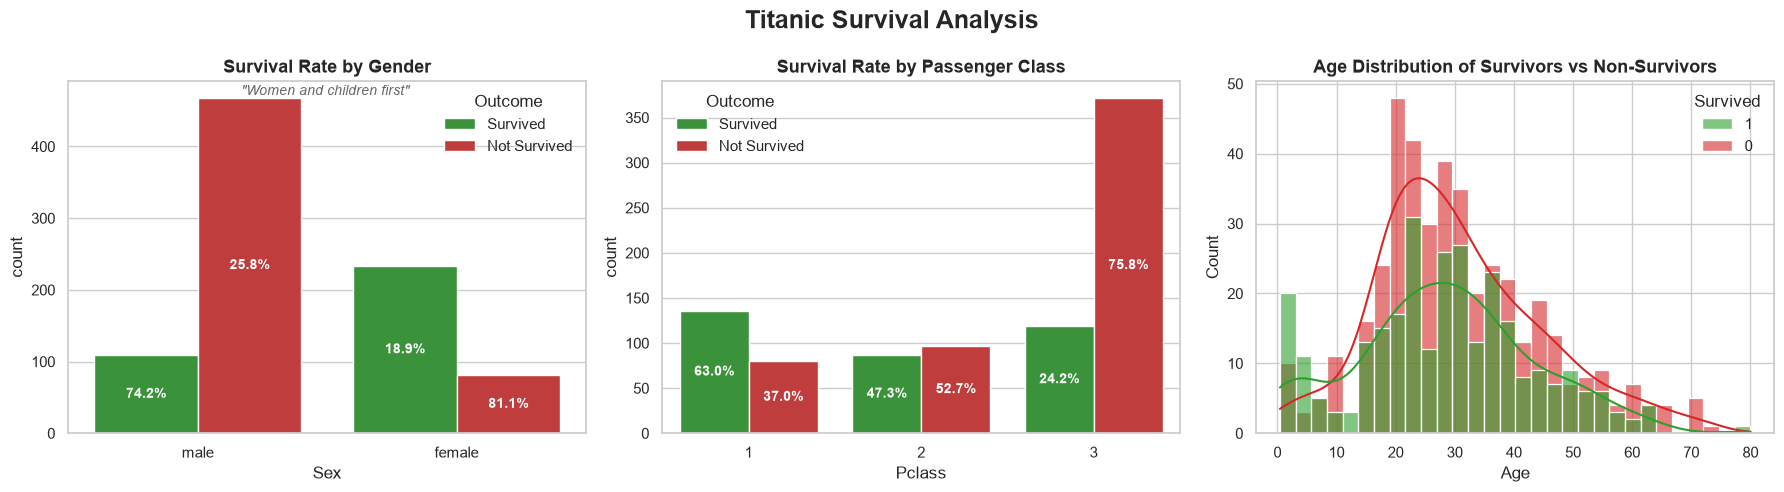

In [16]:
# Styling
sns.set_theme(style="whitegrid")
palette = {1: "#2ca02d", 0: "#d62728"}  # Green = Survived, Red = Not Survived

def add_percentage_labels(ax, data, category_col):
    """
    Add percentage labels inside bars.
    """
    pct_table = (
        pd.crosstab(
            data[category_col],
            data["Survived"],
            normalize="index"
        ) * 100
    )

    # Match hue_order=[1, 0]
    for container, surv_status in zip(ax.containers, [1, 0]):
        for bar, pct in zip(container, pct_table[surv_status]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=10,
                fontweight="bold"
            )

# Create layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==================================================
# Survival by Gender
# ==================================================
ax = sns.countplot(
    data=train_df,
    x="Sex",
    hue="Survived",
    hue_order=[1, 0],  # Survived first
    palette=palette,
    ax=axes[0]
)

ax.set_title(
    "Survival Rate by Gender",
    fontsize=13,
    fontweight="bold"
)

# Fun annotation
ax.annotate(
    '"Women and children first" ',
    xy=(0.5, 0.96),
    xycoords='axes fraction',
    ha='center',
    fontsize=10,
    style='italic',
    color='dimgray'
)

ax.legend(title="Outcome", labels=["Survived", "Not Survived"])
add_percentage_labels(ax, train_df, "Sex")

# ==================================================
# Survival by Passenger Class
# ==================================================
ax = sns.countplot(
    data=train_df,
    x="Pclass",
    hue="Survived",
    hue_order=[1, 0],
    palette=palette,
    ax=axes[1]
)

ax.set_title(
    "Survival Rate by Passenger Class",
    fontsize=13,
    fontweight="bold"
)

ax.legend(title="Outcome", labels=["Survived", "Not Survived"])
add_percentage_labels(ax, train_df, "Pclass")

# ==================================================
# Age Distribution
# ==================================================
sns.histplot(
    data=train_df,
    x="Age",
    hue="Survived",
    hue_order=[1, 0],
    bins=30,
    kde=True,
    palette=palette,
    alpha=0.6,
    ax=axes[2]
)

axes[2].set_title(
    "Age Distribution of Survivors vs Non-Survivors",
    fontsize=13,
    fontweight="bold"
)

# ==================================================
# Overall Title
# ==================================================
plt.suptitle(
    "Titanic Survival Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 3. Feature Engineering \\

We create a reusable function that generates powerful features and handles missing values consistently for both train and test sets.
Previously, I ran both functions differently but later codex suggested to do in this way, Cool!

In [6]:
def extract_title(name):
    '''Extract and group titles from passenger names.'''
    title_search = re.search(r' ([A-Za-z]+)\.', name)
    if title_search:
        title = title_search.group(1)
        if title in ['Mr', 'Mrs', 'Miss', 'Master']:
            return title
        else:
            return 'Rare'
    return 'Unknown'

def create_features(df, title_medians=None, fare_medians=None, is_train=True):
    '''
    Engineer features for Titanic survival prediction.
    Uses training statistics for consistent imputation on test data.
    '''
    df = df.copy()
    
    # 1. Title
    df['Title'] = df['Name'].apply(extract_title)
    
    # 2. Age imputation using Title medians (learned from train)
    if is_train:
        title_medians = df.groupby('Title')['Age'].median()
    df['Age'] = df['Age'].fillna(df['Title'].map(title_medians))
    df['Age'] = df['Age'].fillna(df['Age'].median())  # fallback
    
    # 3. Fare imputation
    if is_train:
        fare_medians = df.groupby('Pclass')['Fare'].median()
    df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_medians))
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    # 4. Deck from Cabin (generalized)
    df['Deck'] = df['Cabin'].fillna('N').astype(str).str[0]
    df['Deck'] = df['Deck'].replace({'T': 'Rare', 'G': 'Rare'})
    
    # 5. Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # 6. Fare per person + Log transform
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']
    df['LogFare'] = np.log1p(df['Fare'])
    
    # 7. Age bins
    df['AgeBin'] = pd.cut(df['Age'], 
                          bins=[0, 12, 18, 35, 50, 100], 
                          labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
    
    # Drop high-cardinality / leakage columns
    cols_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    
    return df, title_medians, fare_medians

print("✅ Feature engineering functions defined!")

✅ Feature engineering functions defined!


### Apply Feature Engineering to Train and Test

In [8]:
# Process training data
train_processed, title_medians, fare_medians = create_features(train_df, is_train=True)

# Process test data using training statistics (critical for no data leakage)
test_processed, _, _ = create_features(test_df, title_medians=title_medians, 
                                       fare_medians=fare_medians, is_train=False)

print("✅ Feature engineering complete!")
print("\nEngineered columns in train_processed:")
print(list(train_processed.columns))
print("\nSample of new features:")
train_processed[['Title', 'Deck', 'FamilySize', 'IsAlone', 'AgeBin', 'Survived']].head(8)

✅ Feature engineering complete!

Engineered columns in train_processed:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'LogFare', 'Title', 'Deck', 'FamilySize', 'IsAlone', 'FarePerPerson', 'AgeBin']

Sample of new features:


,Title,Deck,FamilySize,IsAlone,AgeBin,Survived
0,Mr,N,2,0,YoungAdult,0
1,Mrs,C,2,0,Adult,1
2,Miss,N,1,1,YoungAdult,1
3,Mrs,C,2,0,YoungAdult,1
4,Mr,N,1,1,YoungAdult,0
5,Mr,N,1,1,YoungAdult,0
6,Mr,E,1,1,Senior,0
7,Master,N,5,0,Child,0


## 4. Prepare Data for Modeling

In [9]:
# Separate target and features
y = train_processed['Survived']
X = train_processed.drop(columns=['Survived'])

# One-hot encode categorical features
categorical_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'AgeBin']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test_processed, columns=categorical_cols, drop_first=True)

# Align columns between train and test (in case test misses some categories)
X_encoded, test_encoded = X_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

print(f"Final training feature shape: {X_encoded.shape}")
print(f"Number of features after encoding: {X_encoded.shape[1]}")

# Scale numeric features (important for Logistic Regression)
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'FarePerPerson', 'LogFare']
scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])
test_encoded[numeric_cols] = scaler.transform(test_encoded[numeric_cols])

print("\n✅ Data ready for modeling!")

Final training feature shape: (891, 28)
Number of features after encoding: 28

✅ Data ready for modeling!


## 5. Model Training & Cross-Validation

We evaluate multiple strong models using **5-fold Stratified Cross-Validation** for reliable performance estimates.


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        n_jobs=-1, eval_metric='logloss', use_label_encoder=False
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, C=0.5
    )
}

results = {}
print("Running 5-fold Cross-Validation...\n")
for name, model in models.items():
    scores = cross_val_score(model, X_encoded, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:20s} → Mean CV Accuracy: {scores.mean():.4f}  (±{scores.std()*2:.4f})")

Running 5-fold Cross-Validation...

Random Forest        → Mean CV Accuracy: 0.8361  (±0.0220)
LightGBM             → Mean CV Accuracy: 0.8395  (±0.0303)
XGBoost              → Mean CV Accuracy: 0.8406  (±0.0446)
Logistic Regression  → Mean CV Accuracy: 0.8227  (±0.0261)


### Voting Ensemble (Recommended Final Model)

In [11]:
# Create soft voting ensemble (gives probability-weighted predictions)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('lgbm', models['LightGBM']),
        ('xgb', models['XGBoost']),
        ('lr', models['Logistic Regression'])
    ],
    voting='soft',
    weights=[1, 2, 2, 1]   # Give higher weight to tree-based models
)

ensemble_scores = cross_val_score(voting_clf, X_encoded, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Voting Ensemble CV Accuracy: {ensemble_scores.mean():.4f} (±{ensemble_scores.std()*2:.4f})")

# Choose best model
best_model_name = max(results, key=lambda k: results[k].mean())
print(f"\nBest single model: {best_model_name}")

Voting Ensemble CV Accuracy: 0.8429 (±0.0217)

Best single model: XGBoost


## 6. Train Final Model on Full Data & Predict

In [12]:
# Train the ensemble on the entire training set
print("Training final Voting Ensemble on full training data...")
final_model = voting_clf
final_model.fit(X_encoded, y)

# Predict on test set
test_predictions = final_model.predict(test_encoded)
test_proba = final_model.predict_proba(test_encoded)[:, 1]

print("✅ Predictions generated!")

Training final Voting Ensemble on full training data...
✅ Predictions generated!


## 7. Create Kaggle Submission File

In [13]:
# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

# Save files
submission.to_csv('C:\\Users\\shubh\\Documents\\GREAT LAKES 2025-26\\Data analytics projects+practicals\\titanic\\submission_improved.csv', index=False)

# Also save with probabilities for analysis
submission_with_proba = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived_Prob': test_proba.round(4),
    'Survived': test_predictions
})
submission_with_proba.to_csv('C:\\Users\\shubh\\Documents\\GREAT LAKES 2025-26\\Data analytics projects+practicals\\titanic\\submission_with_proba.csv', index=False)

print("✅ Files saved successfully!")
print("\nSubmission file preview:")
print(submission.head(12).to_string(index=False))
print(f"\nTotal predictions: {len(submission)}")
print(f"Predicted survival rate: {submission['Survived'].mean():.2%}")

✅ Files saved successfully!

Submission file preview:
 PassengerId  Survived
         892         0
         893         0
         894         0
         895         0
         896         1
         897         0
         898         0
         899         0
         900         1
         901         0
         902         0
         903         0

Total predictions: 418
Predicted survival rate: 36.60%


## 8. Summary 

**You now have a production-ready, well-engineered Titanic model!** 🎉

Upload `submission_improved.csv` to Kaggle

https://www.kaggle.com/competitions/titanic/submissions
# Kaggle Final Prediction score: 77.9% #
